### Notebook modelo de árbol de decisión y vecinos cercanos

En esta sesión nos concentraremos en la aplicación práctica de ambos modelos usando un pequeño conjunto de datos de habitabilidad de exoplanetas.

**Objetivos:**
- entrenar un **árbol de decisión** y un clasificador **kNN** con `scikit-learn`,
- interpretar predicciones y calcular `accuracy`,
- comparar ambos métodos en un mismo problema,
- entender por qué **kNN requiere escalamiento** de variables y los árboles no necesariamente.


(Adaptado de  Viviana Acquaviva (2023))



## Decision Trees

https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html


https://www.kaggle.com/code/willkoehrsen/visualize-a-decision-tree-w-python-scikit-learn

In [ ]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd


In [ ]:
# Comentamos para una mejor visualización de los gráficos
# font = {'size'   : 10}
# matplotlib.rc('font', **font)
# matplotlib.rc('xtick', labelsize=10)
# matplotlib.rc('ytick', labelsize=10)
# matplotlib.rcParams['figure.dpi'] = 200

In [ ]:
#Paquetes para visualización

from io import StringIO
from IPython.display import Image
import pydotplus

from sklearn.tree import export_graphviz

### Subconjunto de base de datos de Habitabilidad de planetas https://phl.upr.edu/projects/habitable-exoplanets-catalog

In [ ]:
LearningSet = pd.read_csv('HPLearningSet.csv', index_col=0)

**Variables:**
- `S_MASS`: masa estelar ($M_\odot$)
- `P_PERIOD`: período orbital (días)
- `P_DISTANCE`: distancia planeta–estrella (AU)
- `P_HABITABLE`: clase objetivo (0 = no habitable, 1 = habitable)


In [ ]:
LearningSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
0,Kepler-736 b,0.86,3.601472,0.043718,0
1,Kepler-636 b,0.85,16.080661,0.118082,0
2,Kepler-887 c,1.19,7.638460,0.080420,0
3,Kepler-442 b,0.61,112.305300,0.409327,1
4,Kepler-772 b,0.98,12.992073,0.107408,0
5,Teegarden's Star b,0.09,4.910000,0.025200,1
6,K2-116 b,0.69,4.655411,0.048086,0
7,GJ 1061 c,0.12,6.689000,0.035000,1
8,HD 68402 b,1.12,1103.000000,2.180981,0
9,Kepler-1544 b,0.81,168.811170,0.557107,1


### Haga una revisión rápida del set de datos
- Encuentre el tamaño del dataset, y las categorías de la variable `P_HABITABLE` y los ejemplos en cada categoría.
- También visualice la relación entre la masa, el periodo y la habitabilidad del planeta. Grafique el periodo en escala log

In [ ]:
df = pd.DataFrame(LearningSet)
Habitabilidad = df[df["P_HABITABLE"] == 1]
Habitabilidad

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
3,Kepler-442 b,0.61,112.305300,0.409327,1
5,Teegarden's Star b,0.09,4.910000,0.025200,1
7,GJ 1061 c,0.12,6.689000,0.035000,1
9,Kepler-1544 b,0.81,168.811170,0.557107,1
10,Kepler-296 e,0.50,34.142110,0.178202,1
11,Kepler-705 b,0.53,56.056054,0.231926,1
15,Kepler-296 f,0.50,63.336270,0.268885,1
17,GJ 3293 d,0.42,48.134500,0.195336,1


In [ ]:
print (len(LearningSet))

18


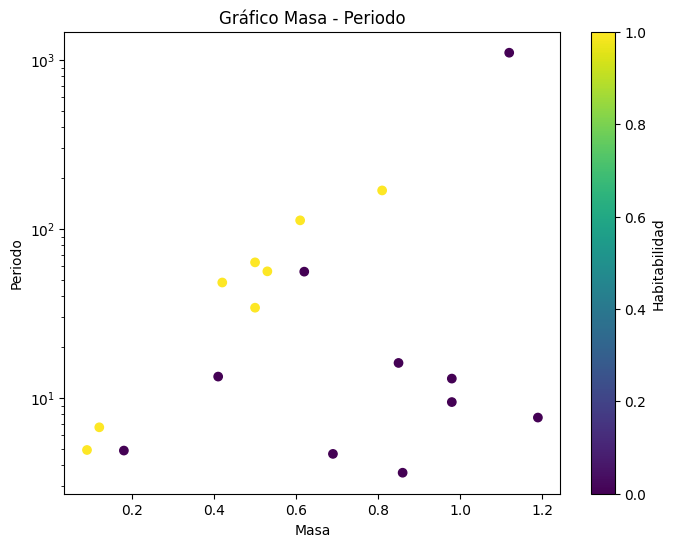

In [ ]:
plt.figure(figsize = (8,6))
scatter_plot = plt.scatter(df["S_MASS"], df["P_PERIOD"], c=df["P_HABITABLE"])
plt.colorbar(scatter_plot, label="Habitabilidad")
plt.yscale("log")
plt.xlabel("Masa")
plt.ylabel("Periodo")
plt.title("Gráfico Masa - Periodo")
plt.show()

**Antes de entrenar un modelo, te parece que las clases se separan fácilmente o no? Explique**


Analizando el gráfico, podemos notar que los planetas habitables se separan notoriamente de los planetas no habitables. Visualmente, sería representando más o menos una recta diagonal. Por lo que, antes de entrenar algún modelo, notamos una separación de clases sencilla.

### Elijamos el set de entrenamiento y prueba

Para definir los sets de etrenamiento y prueba, haremos una división *manual*

Definimos que las primeras 13 filas del dataframe será el conjunto de entrenamiento y los últimos 5, el conjunto de prueba

> En un problema real, usualmente preferimos una división aleatoria o validación cruzada.


Usaremos .iloc para acceder a los índices del dataframe

In [ ]:
LearningSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
0,Kepler-736 b,0.86,3.601472,0.043718,0
1,Kepler-636 b,0.85,16.080661,0.118082,0
2,Kepler-887 c,1.19,7.638460,0.080420,0
3,Kepler-442 b,0.61,112.305300,0.409327,1
4,Kepler-772 b,0.98,12.992073,0.107408,0
5,Teegarden's Star b,0.09,4.910000,0.025200,1
6,K2-116 b,0.69,4.655411,0.048086,0
7,GJ 1061 c,0.12,6.689000,0.035000,1
8,HD 68402 b,1.12,1103.000000,2.180981,0
9,Kepler-1544 b,0.81,168.811170,0.557107,1


In [ ]:
TrainSet =  LearningSet.iloc[:13,:]

TestSet = LearningSet.iloc[13:,:]

In [ ]:
TrainSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
0,Kepler-736 b,0.86,3.601472,0.043718,0
1,Kepler-636 b,0.85,16.080661,0.118082,0
2,Kepler-887 c,1.19,7.638460,0.080420,0
3,Kepler-442 b,0.61,112.305300,0.409327,1
4,Kepler-772 b,0.98,12.992073,0.107408,0
5,Teegarden's Star b,0.09,4.910000,0.025200,1
6,K2-116 b,0.69,4.655411,0.048086,0
7,GJ 1061 c,0.12,6.689000,0.035000,1
8,HD 68402 b,1.12,1103.000000,2.180981,0
9,Kepler-1544 b,0.81,168.811170,0.557107,1


In [ ]:
TestSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
13,HD 104067 b,0.62,55.80600,0.260000,0
14,GJ 4276 b,0.41,13.35200,0.087613,0
15,Kepler-296 f,0.50,63.33627,0.268885,1
16,Kepler-63 b,0.98,9.43415,0.088100,0
17,GJ 3293 d,0.42,48.13450,0.195336,1


También necesitamos definir para cada conjunto las características (features) y los objetivos (targets)

In [ ]:
Xtrain = TrainSet.drop(['P_NAME','P_HABITABLE'],axis=1) #features conjunto de entrenamiento #El nombre y la etiqueta hay que exluirlos

Xtest = TestSet.drop(['P_NAME','P_HABITABLE'],axis=1) #features  conjunto de entrenamiento

In [ ]:
Xtrain.columns

Index(['S_MASS', 'P_PERIOD', 'P_DISTANCE'], dtype='object')

In [ ]:
ytrain = TrainSet.P_HABITABLE #target conjunto prueba

ytest = TestSet.P_HABITABLE  #target conjunto prueba

In [ ]:
Xtest

,S_MASS,P_PERIOD,P_DISTANCE
13,0.62,55.80600,0.260000
14,0.41,13.35200,0.087613
15,0.50,63.33627,0.268885
16,0.98,9.43415,0.088100
17,0.42,48.13450,0.195336


In [ ]:
ytrain

,P_HABITABLE
0,0
1,0
2,0
3,1
4,0
5,1
6,0
7,1
8,0
9,1


### Entrenamos el modelo
Nota: En los árboles de decisión de scikit-learn, las características (o variables) se reorganizan aleatoriamente cada vez que se realiza una división para decidir cómo separar los datos. Esto significa que, incluso si se usa el mismo conjunto de datos de entrenamiento, la mejor forma de dividir los datos puede cambiar entre diferentes ejecuciones del modelo. Esta variación ocurre cuando varias divisiones posibles ofrecen la misma mejora en el criterio de evaluación (por ejemplo, reducir la impureza del nodo). En estos casos, el algoritmo puede elegir diferentes divisiones como "mejores" en diferentes ejecuciones debido al orden aleatorio en que se evalúan las características.

Para asegurar que los resultados del entrenamiento sean consistentes y reproducibles (es decir, que se obtenga el mismo árbol de decisión cada vez que se entrene con los mismos datos), es necesario fijar el parámetro random_state. Esto establece una semilla para el generador de números aleatorios utilizado por el algoritmo, garantizando que la permutación de las características sea la misma en cada ejecución y, por lo tanto, el resultado del modelo también sea el mismo.

In [ ]:
from sklearn.tree import DecisionTreeClassifier #modelo de árbol de decisión


In [ ]:
model = DecisionTreeClassifier(random_state = 3) #Inicializamos el modelo con sus parámetros

model.fit(Xtrain, ytrain) #En una línea, construimos el modelo

DecisionTreeClassifier(random_state=3)

### Podemos visualizar el árbol (visualización "pro")

debe instalar la libreria [`pydotplus`](https://pypi.org/project/pydotplus/)  y [`graphviz`](https://pypi.org/project/graphviz/)

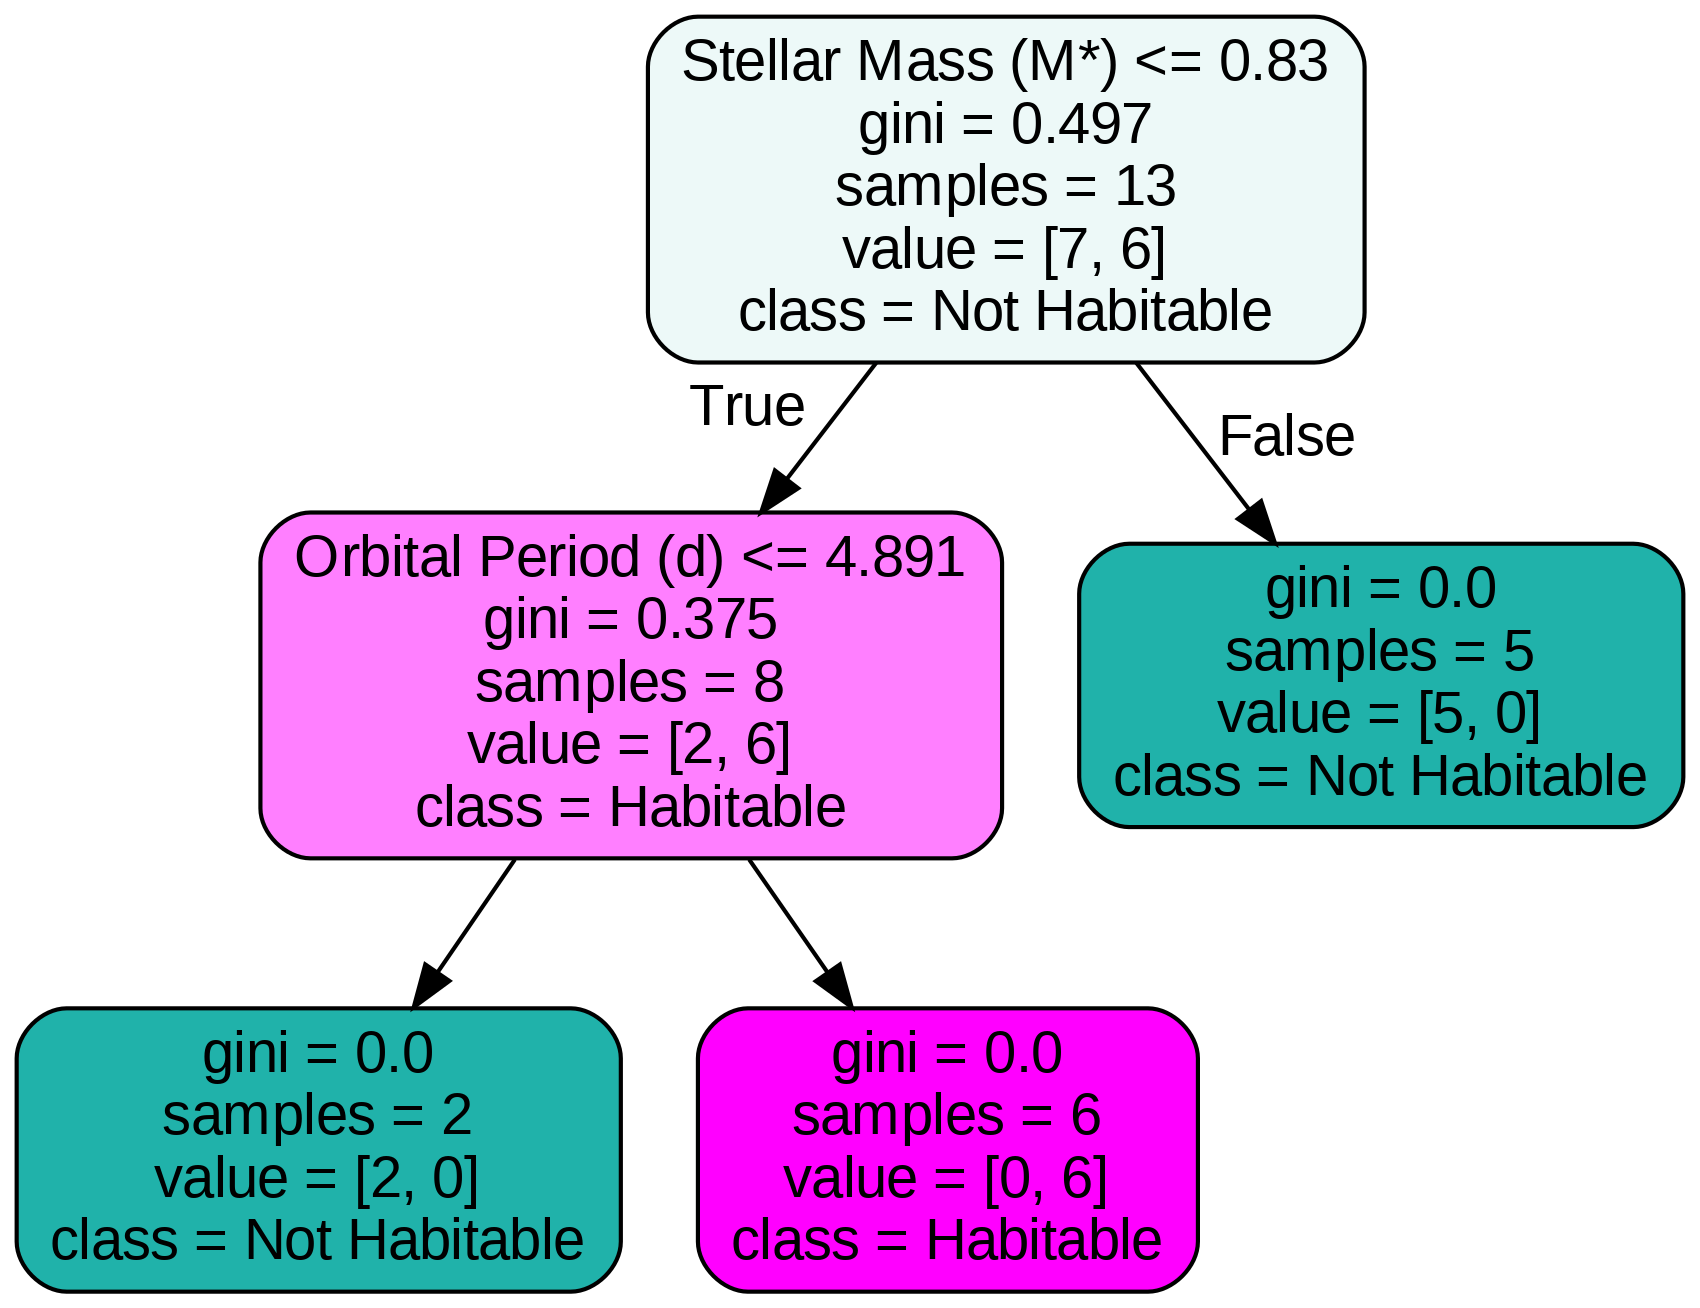

In [ ]:
dot_data = StringIO()
export_graphviz(
            model,
            out_file =  dot_data,
            feature_names = ['Stellar Mass (M*)', 'Orbital Period (d)', 'Distance (AU)'],
            class_names = ['Not Habitable','Habitable'],
            filled = True,
            rounded = True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue().replace("\n", ""))
nodes = graph.get_node_list()

for node in nodes:
    if node.get_label():
        values = [int(ii) for ii in node.get_label().split('value = [')[1].split(']')[0].split(',')]
        values = [255 * v / sum(values) for v in values]

        values = [int(255 * v / sum(values)) for v in values]

        if values[0] > values[1]:
            alpha = int(values[0] - values[1])
            alpha = '{:02x}'.format(alpha) #turn into hexadecimal
            color = '#20 B2 AA'+str(alpha)
        else:
            alpha = int(values[1] - values[0])
            alpha = '{:02x}'.format(alpha)
            color = '#FF 00 FF'+str(alpha)
        node.set_fillcolor(color)

graph.set_dpi('300')

Image(graph.create_png())

#Image(graph.write_png('Graph.png'))

### Visualización de sklearn

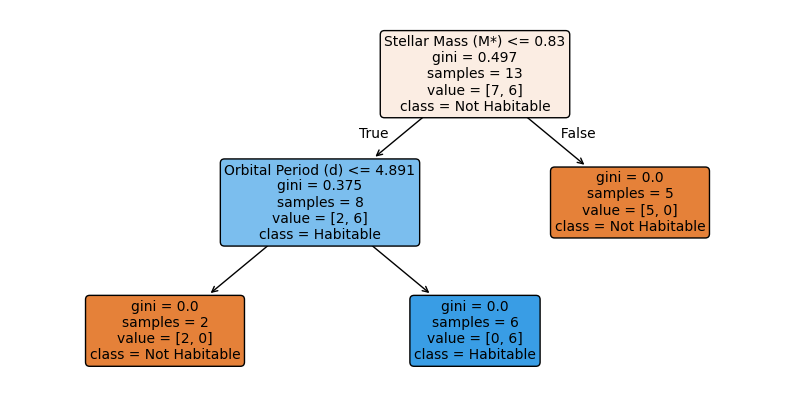

In [ ]:
from sklearn import tree

plt.figure(figsize=(10,5))  # puede cambiar de acuerdo al tamaño del árbol
tree.plot_tree(model,
               feature_names = ['Stellar Mass (M*)', 'Orbital Period (d)', 'Distance (AU)'],
               class_names = ['Not Habitable','Habitable'],
               filled=True,
               rounded=True,
               fontsize=10)

plt.show()

### También podemos visualizar las decisiones del clasificador. El color de sombreado predice la etiqueta, y el color de los puntos marca la etiqueta real:

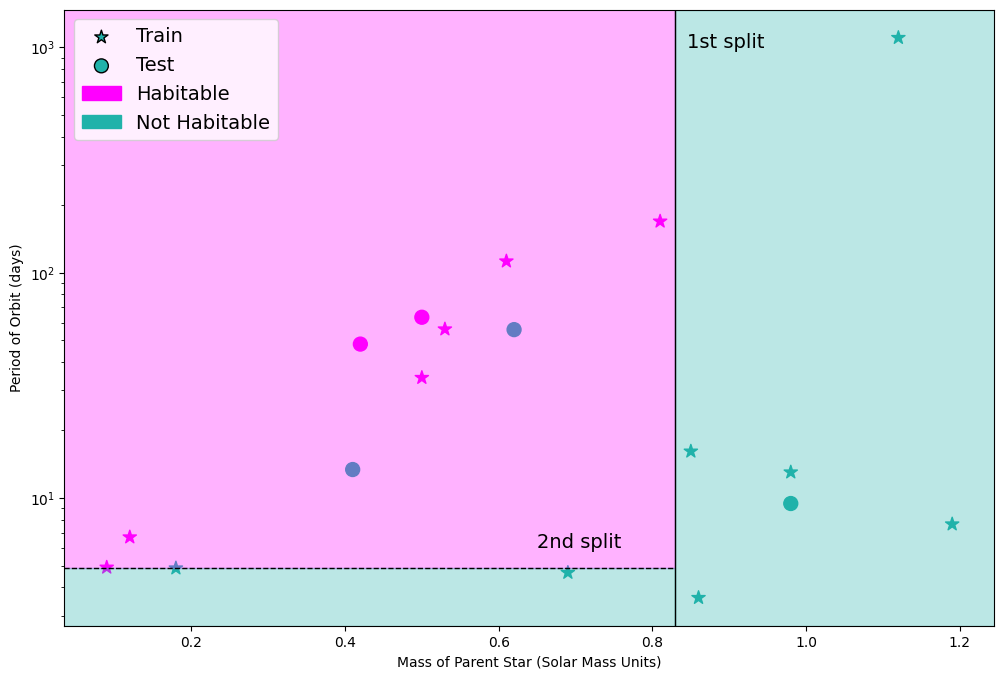

In [ ]:
plt.figure(figsize=(12,8))

cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#20B2AA','#FF00FF'])

#puntos de entrenamiento y prueba

plt.scatter(TrainSet['S_MASS'], TrainSet['P_PERIOD'], marker = '*',\
            c = TrainSet['P_HABITABLE'], s = 100, cmap=cmap, label = 'Train')

plt.scatter(TestSet['S_MASS'], TestSet['P_PERIOD'], marker = 'o',\
            c = TestSet['P_HABITABLE'], s = 100, cmap=cmap, label = 'Test')

plt.yscale('log')

plt.xlabel('Mass of Parent Star (Solar Mass Units)')

plt.ylabel('Period of Orbit (days)');

#splits del gráfico

plt.axvline(x=0.83, linewidth =1, ls = '-', label = '1st split', c='k')

plt.axhline(y=4.891, xmin = 0, xmax = 0.655, linewidth =1, ls = '--', label = '2nd split',c='k')

plt.text(0.845, 10**3, '1st split', fontsize=14)

plt.text(0.65, 6, '2nd split', fontsize=14)

#leyenda

bluepatch = mpatches.Patch(color='#20B2AA', label='Not Habitable')

magentapatch = mpatches.Patch(color='#FF00FF', label='Habitable')

plt.legend();

ax = plt.gca()

predhab = mpatches.Rectangle((0,4.891),0.83,ax.get_ylim()[1],
                        fill = True,
                        color = '#FF00FF',
                        alpha = 0.3)

prednothab1 = mpatches.Rectangle((0.83,ax.get_ylim()[0]),ax.get_xlim()[1],ax.get_ylim()[1],
                        fill = True,
                        color = '#20B2AA',
                        alpha = 0.3)

prednothab2 = mpatches.Rectangle((0,ax.get_ylim()[0]),0.83,4.891-ax.get_ylim()[0],
                        fill = True,
                        color = '#20B2AA',
                        alpha = 0.3)

leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[1].set_color('k')

plt.gca().add_patch(predhab)
plt.gca().add_patch(prednothab1)
plt.gca().add_patch(prednothab2)

leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[1].set_color('k')


plt.legend(handles=[leg.legend_handles[0],leg.legend_handles[1], magentapatch, bluepatch],\
           loc = 'upper left', fontsize = 14);


### Pregunta
    
- ¿Cuál es el porcentaje de clasificaciones correctas en el set de entrenamiento?  Y en el set de prueba?


A este porcentaje de clasificaciones correctas lo llamaremos **accuracy**

In [ ]:
#Utilizamos score para poder ver el porcentaje de clasificaciones correctas
acc_train = model.score(Xtrain, ytrain) * 100 #El 100 es para que se vean como porcentajes
acc_test = model.score(Xtest, ytest) * 100

print(f"Porcentaje Entrenamiento: {acc_train}%")
print(f"Porcentaje Prueba: {acc_test}%")

Porcentaje Entrenamiento: 100.0%
Porcentaje Prueba: 60.0%


Usando la opción de score, podemos ver que el set de entrenamiento tiene un 100% de clasificaciones correctas.
El set de prueba, sin embargo, tiene un 60% de clasificaciones correctas.

### usando la métricas de sklearn, podemos encontrar el accuracy


In [ ]:
import sklearn.metrics as metrics


In [ ]:
ypred = model.predict(Xtest) #generamos etiquetas de predicción en el set de prueba

In [ ]:
ypred

array([1, 1, 1, 0, 1])

Accuracy es una métrica usual para evaluar modelos de clasificación, y hay una función en el módulo `sklearn.metrics`. Tenemos que comparar los resultados de la predicción `ypred` con los valores reales `ytest`

In [ ]:
metrics.accuracy_score(ytest, ypred) #test score

0.6

también podemos encontrar el accuracy de los datos de entrenamiento, generando predicciones para los `Xtrain` y comparando con el `ytrain`

In [ ]:
#Como no le dimos ningun hiperparámetro, el sistema va a buscar un GINI cero, es decir, que está sobreajustado.
metrics.accuracy_score(ytrain, model.predict(Xtrain)) #train score

1.0

### Preguntas de interpretación
1. ¿El árbol clasifica perfectamente el conjunto de entrenamiento?
2. ¿Qué ocurre en el conjunto de prueba?
3. ¿Qué variable aparece en la raíz del árbol?
4. ¿Te parece que este árbol es simple o ya es relativamente profundo para un dataset tan pequeño?


1. Viendo y comparando las métricas de entrenamiento y prueba, notamos que no son perfectas en realidad. En el entrenamiento tenemos un score del 60%, sin embargo el sistema está sobreajustado, lo que se ve reflejado en el entrenamiento.

2. En el conjunto de prueba tenemos un porcentaje de clasificaciones correctas menor al 100%

3. La variable que aparece en la raíz es la masa de la estrella. Desde ahí comienza el filtro.

4. Considerando el dataset, es relatiamente simple ya que solo hay dos splits visualmente hablando.

### Ahora elegiremos un set de entrenamiento distinto. Las 5 primeras filas serán de prueba y el resto será para el entrenamiento

In [ ]:
# los primeros 5 de prueba, el resto de entrenamiento
TrainSet2 = LearningSet.iloc[5:,:]

TestSet2 = LearningSet.iloc[:5,:]

### Repita el proceso anterior

1. Defina los dataframes de características y la serie de categorías para entrenamiento y prueba: `Xtrain2`, `Xtest2`, `ytrain2`, `ytest2`
2. inicialice el modelo de árbol de decisión para clasificación (defina semilla `random_state=3`
3. ajuste el modelo a los datos de entrenamiento
4. visualice el árbol
5. calcule accuracy para entrenamiento y prueba

In [ ]:
TrainSet2

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
5,Teegarden's Star b,0.09,4.910000,0.025200,1
6,K2-116 b,0.69,4.655411,0.048086,0
7,GJ 1061 c,0.12,6.689000,0.035000,1
8,HD 68402 b,1.12,1103.000000,2.180981,0
9,Kepler-1544 b,0.81,168.811170,0.557107,1
10,Kepler-296 e,0.50,34.142110,0.178202,1
11,Kepler-705 b,0.53,56.056054,0.231926,1
12,Kepler-445 c,0.18,4.871229,0.031746,0
13,HD 104067 b,0.62,55.806000,0.260000,0
14,GJ 4276 b,0.41,13.352000,0.087613,0


In [ ]:
Xtrain2 = TrainSet2.drop(['P_NAME','P_HABITABLE'],axis=1)

Xtest2 = TestSet2.drop(['P_NAME','P_HABITABLE'],axis=1)

In [ ]:
Xtrain.columns

Index(['S_MASS', 'P_PERIOD', 'P_DISTANCE'], dtype='object')

In [ ]:
ytrain2 = TrainSet2.P_HABITABLE

ytest2 = TestSet2.P_HABITABLE

In [ ]:
Xtest2

,S_MASS,P_PERIOD,P_DISTANCE
0,0.86,3.601472,0.043718
1,0.85,16.080661,0.118082
2,1.19,7.638460,0.080420
3,0.61,112.305300,0.409327
4,0.98,12.992073,0.107408


In [ ]:
ytrain2

,P_HABITABLE
5,1
6,0
7,1
8,0
9,1
10,1
11,1
12,0
13,0
14,0


In [ ]:
model2 = DecisionTreeClassifier(random_state = 3)

model2.fit(Xtrain2, ytrain2)

DecisionTreeClassifier(random_state=3)

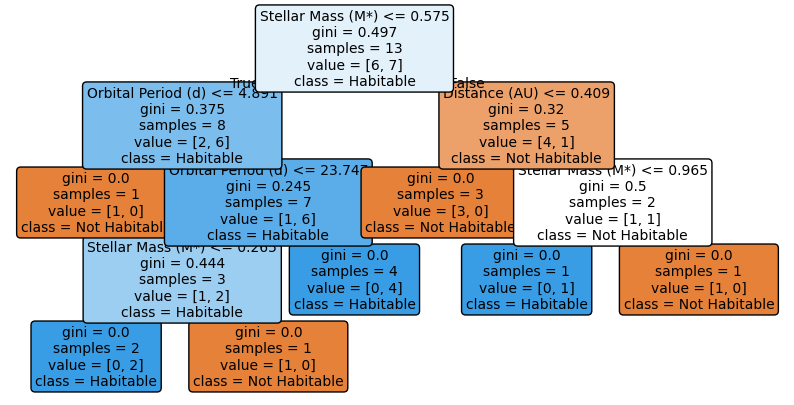

In [ ]:
plt.figure(figsize=(10,5))
tree.plot_tree(model2,
               feature_names = ['Stellar Mass (M*)', 'Orbital Period (d)', 'Distance (AU)'],
               class_names = ['Not Habitable','Habitable'],
               filled=True,
               rounded=True,
               fontsize=10)

plt.show()

In [ ]:
ypred2 = model2.predict(Xtest2)

In [ ]:
ypred2

array([0, 0, 0, 1, 0])

In [ ]:
metrics.accuracy_score(ytest2, ypred2)

1.0

In [ ]:
metrics.accuracy_score(ytrain2, model2.predict(Xtrain2))

1.0

In [ ]:
#Este árbol tiene muchas más ramas. Aquí usó tres categorías (dist. orbital).
#Hicimos un pequeño cambio en el set de datos y tenemos resultados muy distintos.

### Preguntas:

- Compare el árbol de decisión inicial vs el obtenido ahora. Nota alguna diferencia?

- ¿Cuál es el accuracy (porcentaje de clasificaciones correctas) en el conjunto de entrenamiento?

- ¿Y en el conjunto de prueba?

- Si ahora el resultado es mejor, ¿significa automáticamente que este árbol es “mejor” en general?


1. El árbol de decisión inicial que vemos es mucho más sencillo en comparación a este nuevo árbol, que es más complejo y tiene muchas más ramas.

2. En el porcentaje para el conjunto de entrenamiento tenemos un 100%

3. En el porcentaje para el conjunto de prueba también tenemos un 100%

4. A pesar de que el resultado sea "perfecto", no significa que el árbol de decisión sea realmente correcto. Esto, por lo general, se considera una advertencia notoria, ya que puede implicar overfitting(sobreajuste). En este caso, debido al tamaño tan reducido de la muestra y que anteriormente ya teniamos un sobreajuste, es mucho más fácil que prediga un conjunto de datos tan pequeño.

In [ ]:
tierra = pd.DataFrame({
    "S_MASS": [1.0], #1 Masa solar
    "P_PERIOD": [365.25], #Un año
    "P_DISTANCE": [1] #1 AU
})
#Modelo 1
prediccion_tierra = model.predict(tierra)
if prediccion_tierra[0] == 1:
    print(f"HABITABLE {prediccion_tierra[0]}")
else:
    print(f"NO HABITABLE {prediccion_tierra[0]}")

#Modelo 2
prediccion_tierra_2 = model2.predict(tierra)
if prediccion_tierra[0] == 1:
    print(f"HABITABLE {prediccion_tierra_2[0]}")
else:
    print(f"NO HABITABLE {prediccion_tierra_2[0]}")

NO HABITABLE 0
NO HABITABLE 0


### Conclusiones

- Que puede concluir respecto a al ejercicio?

- Cambian los resultados dependiendo del set de datos que utilizamos?

- ¿Sería la Tierra clasificada como habitable por alguno de estos árboles?

Los árboles de decisión son un tipo de ML más "visual", que también requieren de hiperparámetros claros o el sistema buscará siempre un Gini perfecto, aprendiendose los datos y generando overfitting. Si el set de datos es muy acotado, la predicción será más sencilla y puede que se hayan acertado porque eran casos sencillos o porque se memorizó el patrón que justo logra encajar con los ejemplos.
Con un código rápido pasando por este modelo los datos de la Tierra, obtenemos que esta es clasificada por no habitable por ambos.

## k-Nearest Neighbors

Aplicaremos ahora kNN al mismo problema.

>kNN clasifica según las etiquetas de los `k` vecinos más cercanos, es un método basado en distancia, por eso la **escala** de las variables sí importa.




In [ ]:
from sklearn import neighbors
import sklearn

Para el mismo set de datos de habitabilidad de planetas

In [ ]:
Xtrain

,S_MASS,P_PERIOD,P_DISTANCE
0,0.86,3.601472,0.043718
1,0.85,16.080661,0.118082
2,1.19,7.638460,0.080420
3,0.61,112.305300,0.409327
4,0.98,12.992073,0.107408
5,0.09,4.910000,0.025200
6,0.69,4.655411,0.048086
7,0.12,6.689000,0.035000
8,1.12,1103.000000,2.180981
9,0.81,168.811170,0.557107


### "Entrenamos" el modelo
Es un algoritmo sencillo basado en la idea de distancia: buscamos los k (un número entero) objetos que están más cerca del que queremos clasificar, y tomamos la votación de la mayoría entre las k clases de los k vecinos.

kNN es un algoritmo basado en instancias (también llamado **"lazy learning"**), sigue necesitando saber con qué datos va a comparar para hacer predicciones futuras. El método fit le dice al algoritmo con qué datos va a trabajar.

El método fit en kNN no ajusta parámetros del modelo como en otros algoritmos.
Simplemente almacena los datos de entrenamiento para su uso durante la predicción.
Durante la predicción, el algoritmo calcula las distancias entre el nuevo punto y los puntos de entrenamiento almacenados para encontrar los k vecinos más cercanos y decidir la clase del nuevo punto basado en una votación mayoritaria.
En esencia, el proceso de "ajuste" en kNN es solo la configuración de los datos de referencia para comparaciones futuras, no un ajuste de parámetros basado en optimización.









In [ ]:
model = neighbors.KNeighborsClassifier(n_neighbors = 3) #elegimos los 3 vecinos más cercanos

In [ ]:
model

KNeighborsClassifier(n_neighbors=3)

#### Para propósitos de visualización, usemos solo las dos primeras características para construir el modelo.

In [ ]:
Xtrain.iloc[:,:2]

,S_MASS,P_PERIOD
0,0.86,3.601472
1,0.85,16.080661
2,1.19,7.638460
3,0.61,112.305300
4,0.98,12.992073
5,0.09,4.910000
6,0.69,4.655411
7,0.12,6.689000
8,1.12,1103.000000
9,0.81,168.811170


#### Se construye el modelo aplicando el método .fit al conjunto de entrenamiento. Luego, predice las etiquetas para el conjunto de prueba.

In [ ]:
model.fit(Xtrain.iloc[:,:2],ytrain) #esto ajusta el modelo que se usa para hacer predicciones en nuevas instancias
ytestpred = model.predict(Xtest.iloc[:,:2]) #esto ajsta el modelo en los datos de prueba

In [ ]:
ytestpred, ytest.values #comparacion

(array([1, 0, 1, 0, 1]), array([0, 0, 1, 0, 1]))

#### Calculando accuracy en los sets de entrenamiento y prueba

In [ ]:
print(metrics.accuracy_score(ytrain, model.predict(Xtrain.iloc[:,:2]))) #Esto compara las etiquetas reales del set de entrenamiento con las etiquetas predichas para el test de entrenamiento

print(metrics.accuracy_score(ytest, model.predict(Xtest.iloc[:,:2]))) #mismo que anterior, pero para set de prueba

0.6923076923076923
0.8


#### Después de ajustar y la predicción, podemos ver los k neighbors que encontró el modelo en el conjunto de prueba

In [ ]:
model.kneighbors(Xtest.iloc[:,:2]) #el primer elemento es la distancia, el segundo los índices de cada vecinos

(array([[ 0.26575741, 21.66422235, 39.72600482],
        [ 0.67412717,  2.76390862,  5.76653597],
        [ 7.28027781, 29.19416   , 47.25690512],
        [ 1.807928  ,  2.87670841,  3.5579225 ],
        [ 7.9223177 , 13.99261869, 32.05672308]]),
 array([[11, 10,  1],
        [ 4,  1,  2],
        [11, 10,  1],
        [ 2,  7,  4],
        [11, 10,  1]]))

### Visualizando los resultados

USamos la distancia del tercer vecino como el radio del círculo que encierra vecinos


In [ ]:
for i in range(len(TestSet)): # para cada elemento del set de prueba

    print(model.kneighbors(Xtest.iloc[:,:2])[0][i,2]) # muestra el tercer elemento del vector de distancia

39.7260048163029
5.766535965914376
47.2569051246575
3.5579225
32.05672308015779


El siguiente código dibuja un círculo incluyendo a los 3 vecinos más cercanos para cada punto

### Nota: Para la aplicación real (no la visualización), debiéramos usar todas las features disponibles

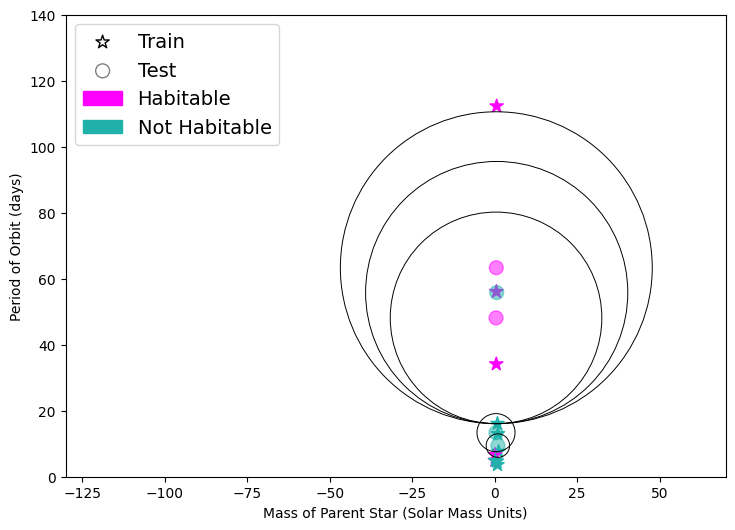

In [ ]:
plt.figure(figsize=(10,6))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#20B2AA','#FF00FF'])


a= plt.scatter(TrainSet['S_MASS'], TrainSet['P_PERIOD'], marker = '*',facecolor = 'None',\
            c = TrainSet['P_HABITABLE'], s = 100, label = 'Train', cmap=cmap)

#a.set_facecolor('none')


a= plt.scatter(TestSet['S_MASS'], TestSet['P_PERIOD'], marker = 'o',facecolor = 'None',\
            c = TestSet['P_HABITABLE'], s = 100, label = 'Test', cmap=cmap, alpha=0.5)

#a.set_facecolor('none')

for i in range(len(TestSet)): #plot neighbors

    circle1=plt.Circle((TestSet['S_MASS'].iloc[i],TestSet['P_PERIOD'].iloc[i]),model.kneighbors(Xtest.iloc[:,:2])[0][i,2],\
                       lw = 0.7, edgecolor='k',facecolor='none')
    plt.gca().add_artist(circle1)

plt.gca().set_aspect(1)

bluepatch = mpatches.Patch(color='#20B2AA', label='Not Habitable')
magentapatch = mpatches.Patch(color='#FF00FF', label='Habitable')

plt.legend();

ax = plt.gca()
leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[0].set_facecolor('none')
leg.legend_handles[1].set_color('k')
leg.legend_handles[1].set_facecolor('none')


plt.legend(handles=[leg.legend_handles[0],leg.legend_handles[1], magentapatch, bluepatch],\
           loc = 'upper left', fontsize = 14)

plt.xlim(-130,70)
plt.ylim(0,140)
plt.xlabel('Mass of Parent Star (Solar Mass Units)')
plt.ylabel('Period of Orbit (days)');

#plt.savefig('HabPlanetsKNN2features.png', dpi = 300)

### Nota algo particular en el gráfico?

Las ordenes de magnitud son muy distintas en el gráfico, eso provoca que haya esa acumulación en la base. Esto implica que tenemos que escalar para poder arreglarlo.

 **Si una dimensión tiene un rango mucho mayor que las otras, dominará el proceso de decisión. Este problema se puede solucionar mediante el <b>escalado</b>. El escalado es un paso de preprocesamiento muy importante para la mayoría de los algoritmos de aprendizaje automático.**



Algunos ejemplos de algoritmos de Scaler [aquí](https://scikit-learn.org/stable/auto_examples/preprocessing/plot_all_scaling.html).

Usaremos [`RobustScaler()`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.RobustScaler.html), que se comporta mejor con outliers que la versión estándar, ya que escala de acuerdo a percentiles. Específicamente, usa la mediana (percentil 50) y el rango intercuartílico (IQR = Q3 - Q1), lo cual lo hace menos sensible a valores extremos


In [ ]:
scaler = sklearn.preprocessing.RobustScaler() #inicializamos el Scaler

#### Importante!!

Debemos ajustar el escalador **sólo con los datos de entrenamiento**. Esto se hace porque **el modelo no debe tener acceso a los datos de prueba durante el entrenamiento**. Si usamos los datos de prueba para ajustar el escalador, estaríamos filtrando información del futuro, lo que se conoce como data leakage.

Esto puede llevar a dos problemas: por un lado, el modelo podría parecer más preciso de lo que realmente es, y por otro, podría aprender patrones que no se generalizan bien a datos nuevos, lo que se traduce en sobreajuste.

Para evitar esto, primero se ajusta el escalador con los datos de entrenamiento (`fit`), y luego se usa ese mismo escalador para transformar tanto el entrenamiento como el test (`transform`).

In [ ]:
scaler.fit(Xtrain) # importante: solo escalamos el set de entrenamiento

RobustScaler()

In [ ]:
scaledXTrain = scaler.transform(Xtrain)

In [ ]:
scaledXTrain

array([[ 0.47222222, -0.18360363, -0.33840183],
       [ 0.44444444,  0.06038761,  0.05671512],
       [ 1.38888889, -0.10467304, -0.14339694],
       [-0.22222222,  1.94175736,  1.60417741],
       [ 0.80555556,  0.        ,  0.        ],
       [-1.66666667, -0.15801948, -0.43679409],
       [ 0.        , -0.16299717, -0.31519247],
       [-1.58333333, -0.12323674, -0.38472405],
       [ 1.19444444, 21.311672  , 11.01745224],
       [ 0.33333333,  3.04655169,  2.38937206],
       [-0.52777778,  0.41352236,  0.3761471 ],
       [-0.44444444,  0.84198052,  0.66159817],
       [-1.41666667, -0.15877753, -0.40201197]])

In [ ]:
scaledXtest = scaler.transform(Xtest) #

In [ ]:
scaler.inverse_transform #esto invierte el escalado si es necesario

<bound method RobustScaler.inverse_transform of RobustScaler()>

**Ahora, con los datos escalados, aplique el modelo de kNN inicializado anteriormente, genere las predicciones y genere la misma visualización que en el caso anterior**

In [ ]:
scaledmodel = neighbors.KNeighborsClassifier(n_neighbors = 3)
scaledXTrain[:,:2]

array([[ 0.47222222, -0.18360363],
       [ 0.44444444,  0.06038761],
       [ 1.38888889, -0.10467304],
       [-0.22222222,  1.94175736],
       [ 0.80555556,  0.        ],
       [-1.66666667, -0.15801948],
       [ 0.        , -0.16299717],
       [-1.58333333, -0.12323674],
       [ 1.19444444, 21.311672  ],
       [ 0.33333333,  3.04655169],
       [-0.52777778,  0.41352236],
       [-0.44444444,  0.84198052],
       [-1.41666667, -0.15877753]])

In [ ]:
scaledmodel.fit(scaledXTrain[:,:2],ytrain)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
scaledytestpred = scaledmodel.predict(scaledXtest[:,:2])

In [ ]:
scaledytestpred, ytest.values

(array([1, 0, 1, 0, 1]), array([0, 0, 1, 0, 1]))

In [ ]:
print(metrics.accuracy_score(ytrain, scaledmodel.predict(scaledXTrain[:,:2])))

print(metrics.accuracy_score(ytest, scaledmodel.predict(scaledXtest[:,:2])))

0.8461538461538461
0.8


In [ ]:
scaledmodel.kneighbors(scaledXtest[:,:2])

(array([[0.2500478 , 0.53900086, 1.00570768],
        [0.47721081, 0.66005572, 0.79614695],
        [0.16494121, 0.57079985, 1.00501058],
        [0.06956397, 0.35230123, 0.38378203],
        [0.34256727, 0.35245873, 1.07701084]]),
 array([[11, 10,  1],
        [10, 12,  6],
        [11, 10,  3],
        [ 4,  0,  1],
        [11, 10, 12]]))

In [ ]:
for i in range(len(TestSet)):

    print(scaledmodel.kneighbors(scaledXtest[:,:2])[0][i,2])

1.0057076822074733
0.7961469534072081
1.0050105812138872
0.3837820313273946
1.0770108415685602


In [ ]:
df_scaledXTrain = pd.DataFrame(scaledXTrain, columns=Xtrain.columns)
df_scaledXTrain

,S_MASS,P_PERIOD,P_DISTANCE
0,0.472222,-0.183604,-0.338402
1,0.444444,0.060388,0.056715
2,1.388889,-0.104673,-0.143397
3,-0.222222,1.941757,1.604177
4,0.805556,0.000000,0.000000
5,-1.666667,-0.158019,-0.436794
6,0.000000,-0.162997,-0.315192
7,-1.583333,-0.123237,-0.384724
8,1.194444,21.311672,11.017452
9,0.333333,3.046552,2.389372


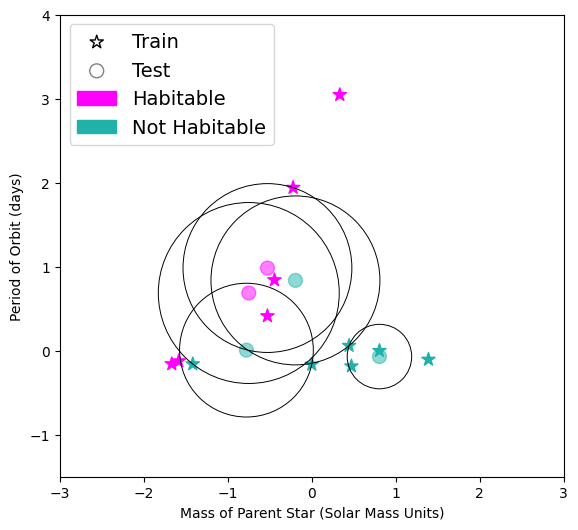

In [ ]:
plt.figure(figsize=(10,6))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#20B2AA','#FF00FF'])

plt.scatter(scaledXTrain[:, 0], scaledXTrain[:, 1], marker = '*',
            c = ytrain, s = 100, label = 'Train', cmap=cmap)

plt.scatter(scaledXtest[:, 0], scaledXtest[:, 1], marker = 'o',
            c = ytest, s = 100, label = 'Test', cmap=cmap, alpha=0.5)

distances, indices = scaledmodel.kneighbors(scaledXtest[:,:2])

for i in range(len(scaledXtest)):
    circle1=plt.Circle((scaledXtest[i,0], scaledXtest[i,1]), distances[i,2],
                       lw = 0.7, edgecolor='k',facecolor='none')
    plt.gca().add_artist(circle1)

plt.gca().set_aspect(1)

bluepatch = mpatches.Patch(color='#20B2AA', label='Not Habitable')
magentapatch = mpatches.Patch(color='#FF00FF', label='Habitable')

plt.legend();

ax = plt.gca()
leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[0].set_facecolor('none')
leg.legend_handles[1].set_color('k')
leg.legend_handles[1].set_facecolor('none')

plt.legend(handles=[leg.legend_handles[0],leg.legend_handles[1], magentapatch, bluepatch],
           loc = 'upper left', fontsize = 14)

plt.xlim(-3, 3)
plt.ylim(-1.5, 4) #Cortamos el outlayer en la parte 23

plt.xlabel('Mass of Parent Star (Solar Mass Units)')
plt.ylabel('Period of Orbit (days)');

plt.show()

**Repita el proceso de kNN escalado, pero usando todas las caracteristicas, y compare el accuracy**

In [ ]:
scaledmodel.fit(scaledXTrain,ytrain)
scaled_ytestpred = scaledmodel.predict(scaledXtest)

In [ ]:
scaled_ytestpred, ytest.values

(array([1, 0, 1, 0, 1]), array([0, 0, 1, 0, 1]))

In [ ]:
print(metrics.accuracy_score(ytrain, scaledmodel.predict(scaledXTrain)))

print(metrics.accuracy_score(ytest, scaledmodel.predict(scaledXtest)))

0.8461538461538461
0.8


In [ ]:
scaledmodel.kneighbors(scaledXtest)

(array([[0.29115916, 0.69239567, 1.2569941 ],
        [0.67779313, 0.7237294 , 0.82338099],
        [0.2564508 , 0.74697027, 1.25174822],
        [0.12395053, 0.41553168, 0.42393826],
        [0.36402651, 0.39388867, 1.37741822]]),
 array([[11, 10,  1],
        [10, 12,  6],
        [11, 10,  3],
        [ 4,  1,  0],
        [10, 11,  6]]))

In [ ]:
for i in range(len(TestSet)):

    print(scaledmodel.kneighbors(scaledXtest)[0][i,2])

1.2569941003916025
0.823380990942238
1.2517482212935696
0.42393826394343254
1.3774182195088278


In [ ]:
df_scaledXTrain_full = pd.DataFrame(scaledXTrain, columns=Xtrain.columns)
df_scaledXTrain_full.head()

,S_MASS,P_PERIOD,P_DISTANCE
0,0.472222,-0.183604,-0.338402
1,0.444444,0.060388,0.056715
2,1.388889,-0.104673,-0.143397
3,-0.222222,1.941757,1.604177
4,0.805556,0.000000,0.000000


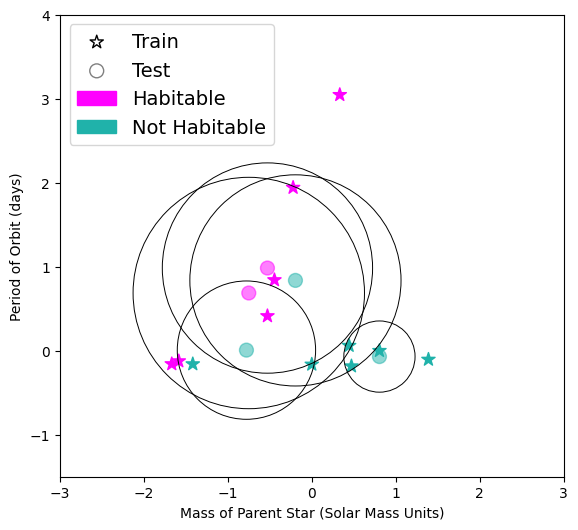

In [ ]:
plt.figure(figsize=(10,6))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#20B2AA','#FF00FF'])

plt.scatter(scaledXTrain[:, 0], scaledXTrain[:, 1], marker = '*',
            c = ytrain, s = 100, label = 'Train', cmap=cmap)

plt.scatter(scaledXtest[:, 0], scaledXtest[:, 1], marker = 'o',
            c = ytest, s = 100, label = 'Test', cmap=cmap, alpha=0.5)

distances, indices = scaledmodel.kneighbors(scaledXtest)

for i in range(len(scaledXtest)):
    circle1=plt.Circle((scaledXtest[i,0], scaledXtest[i,1]), distances[i,2],
                       lw = 0.7, edgecolor='k',facecolor='none')
    plt.gca().add_artist(circle1)

plt.gca().set_aspect(1)

bluepatch = mpatches.Patch(color='#20B2AA', label='Not Habitable')
magentapatch = mpatches.Patch(color='#FF00FF', label='Habitable')

plt.legend();

ax = plt.gca()
leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[0].set_facecolor('none')
leg.legend_handles[1].set_color('k')
leg.legend_handles[1].set_facecolor('none')

plt.legend(handles=[leg.legend_handles[0],leg.legend_handles[1], magentapatch, bluepatch],
           loc = 'upper left', fontsize = 14)

plt.xlim(-3, 3)
plt.ylim(-1.5, 4)

plt.xlabel('Mass of Parent Star (Solar Mass Units)')
plt.ylabel('Period of Orbit (days)');

plt.show()

### Preguntas

- Descubrimos que kNN necesita escalado ¿DT tiene el mismo problema?

- Compare las fortalezas y debilidades de DT y kNN

- ¿Qué diferencia conceptual hay entre cómo clasifica un árbol de decisión y cómo clasifica kNN?

- ¿Por qué el accuracy en entrenamiento no basta para evaluar un modelo?

- ¿Por qué kNN requiere escalamiento y un árbol de decisión no necesariamente?

- Si tuvieras que elegir uno de los dos métodos para este dataset pequeño, ¿cuál elegirías y por qué?


1. Los árboles de decisión no necesariamente requieren de escalado, ya que un DT evalúa con respecto a la característica para hacer splits. Es decir, trabaja con clases.

2. DT es más visual, más sencillo de entender y no requiere de una preparación inicial de datos demasiado compleja. De la misma forma, son más propensos al overfitting y más inestables cuando la base de datos es demasiado extensa. kNN es muy flexible y comprensible, pero se considera lazy learning ya que no aplica un modelado real, sino que trabaja con la estadística, además de que con un exceso de datos empieza a disminuir su rendimiento.

3. DT se basa en dividir en grillas los datos para aislar las categorías de la mejor forma posible, mientras que kNN trabaja con distancias entre un número correspondiente de vecinos con respecto a nuestro punto de interés.

4. Un accuracy del 100% no representa generalmente un modelo perfecto, sino que menciona que se memorizó los datos y no realmente que tan bien puede generalizar.

5. kNN requiere del escalamiento ya que utiliza distancias para trabajar, porque en caso de estar en distintas escalas el cálculo será erróneo.

6. Personalmente, escogería kNN por su versatilidad y su sobreajuste puede ser menor debido a su método de distancias.